# Gabarito — Exercício Final | Semana 06

**SENAI — Visualização de Dados**

Este gabarito resolve cada passo do exercício com explicações detalhadas sobre **o que é**, **por que fazemos** e **o que acontece** em cada etapa.

> **Dica:** leia as explicações antes de olhar o código. O objetivo não é copiar — é entender.

---
## Setup Inicial

Antes de qualquer coisa, importamos as bibliotecas e carregamos a base.

- **`pandas`**: nossa ferramenta principal para trabalhar com tabelas (DataFrames).
- **`numpy`**: usada aqui para gerar números aleatórios (`np.random`) e para representar valores ausentes (`np.nan`).
- **`matplotlib.pyplot`**: para criar gráficos.

Sempre trabalhamos com **uma cópia** da base original — nunca modificamos o arquivo fonte.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../base/base_vendas_supermercado.xlsx")

print(f"Base carregada: {df.shape[0]} linhas | {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")

Base carregada: 250 linhas | 12 colunas
Colunas: ['Data', 'Loja', 'Cliente', 'Categoria', 'Produto', 'Quantidade', 'Preço Unitário', 'Desconto %', 'Valor Bruto', 'Valor Desconto', 'Valor Líquido', 'Forma de Pagamento']


C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\waldinei.rosa\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


---
## Passo 1 — Criando os Dados Sujos

### O que estamos fazendo?

Estamos **simulando problemas reais** que acontecem em bases de dados do mundo real:
- Campos deixados em branco (NaN)
- Valores digitados errado (outliers)
- Registros duplicados

### Por que fazer isso?

A base original já está limpa. Para treinar as técnicas de limpeza, precisamos criar os problemas propositalmente.

---

### `np.random.seed(42)` — O que é isso?

O `seed` (semente) fixa o gerador de números aleatórios. Com o mesmo `seed`, você sempre vai obter **os mesmos números "aleatórios"**. Isso garante que todo aluno que rodar esse código obtenha o mesmo resultado — fundamental para o professor corrigir.

---

### `df.copy()` — Por que copiar?

Em Python, quando você faz `df_raw = df`, você não está criando uma cópia — está criando um **apelido** para o mesmo objeto. Qualquer mudança em `df_raw` mudaria também em `df`. O `.copy()` cria um objeto completamente independente na memória.

---

### `np.random.choice()` — Como inserir NaN em posições aleatórias?

```python
idx = np.random.choice(df_raw.index, n, replace=False)
df_raw.loc[idx, coluna] = np.nan
```

1. `df_raw.index` → lista de todos os índices da tabela (0, 1, 2, ..., 249)
2. `np.random.choice(..., n, replace=False)` → sorteia `n` índices **sem repetição**
3. `df_raw.loc[idx, coluna] = np.nan` → acessa essas linhas na coluna escolhida e substitui por NaN

---

### Por que usamos um `for` para inserir NaN?

Temos duas colunas para sujar (`Categoria` e `Quantidade`). Em vez de escrever o mesmo código duas vezes, usamos um laço que percorre uma lista de pares `(coluna, quantidade)`.

---

### Outliers: o que são?

Outlier = valor "fora do lugar". R$ 5.000 numa venda de supermercado é suspeito. R$ 0,01 também. Esses valores podem ser erros de digitação ou bugs do sistema — e distorcem qualquer análise.

---

### `pd.concat()` para adicionar duplicatas

`df_raw.sample(5, random_state=1)` sorteia 5 linhas aleatórias. Depois, `pd.concat([df_raw, dup])` empilha o DataFrame original com essas 5 linhas repetidas — criando duplicatas.

`ignore_index=True` reinicia a numeração das linhas do zero, evitando índices duplicados.

In [5]:
np.random.seed(42)
df_raw = df.copy()

# Inserindo NaN em colunas específicas
for col, n in [('Categoria', 10), ('Quantidade', 8)]:
    idx = np.random.choice(df_raw.index, n, replace=False)
    df_raw.loc[idx, col] = np.nan

# Inserindo valores absurdos (outliers)
idx_out = np.random.choice(df_raw.index, 3, replace=False)
df_raw.loc[idx_out, 'Valor Líquido'] = [5000, 4500, 0.01]

# Inserindo duplicatas
dup = df_raw.sample(5, random_state=1)
df_raw = pd.concat([df_raw, dup], ignore_index=True)

print(f"Base suja criada:")
print(f"  Linhas     : {df_raw.shape[0]}")
print(f"  NaN total  : {df_raw.isnull().sum().sum()}")
print(f"  Duplicatas : {df_raw.duplicated().sum()}")
print(f"  Máx Valor  : R$ {df_raw['Valor Líquido'].max():.2f}")
print(f"  Mín Valor  : R$ {df_raw['Valor Líquido'].min():.2f}")

Base suja criada:
  Linhas     : 255
  NaN total  : 18
  Duplicatas : 5
  Máx Valor  : R$ 5000.00
  Mín Valor  : R$ 0.01


---
## Passo 2 — Diagnóstico

### Por que diagnosticar antes de limpar?

Limpar sem entender o problema é como tomar remédio sem saber a doença. O diagnóstico responde:
- **Quais colunas** têm NaN?
- **Quanto** da base está afetada?
- **Quantas** linhas são duplicadas?

Essas informações guiam as decisões de limpeza.

---

### `isnull().sum()` — Como funciona?

- `isnull()` → retorna uma tabela de `True`/`False` (True onde há NaN)
- `.sum()` → soma os `True` de cada coluna (em Python, `True = 1` e `False = 0`)
- Resultado: número de NaN por coluna

### `isnull().mean() * 100` — E o percentual?

`.mean()` calcula a média dos `True`/`False` — ou seja, a proporção de NaN. Multiplicando por 100, temos o percentual.

### `duplicated().sum()` — Como funciona?

`duplicated()` retorna `True` para cada linha que é uma cópia de uma linha anterior. `.sum()` conta quantas são.

In [4]:
# --- NaN por coluna ---
nan_contagem = df_raw.isnull().sum()
nan_pct      = (df_raw.isnull().mean() * 100).round(1)

print("=== Percentual de NaN por coluna ===")
for col in df_raw.columns:
    if nan_contagem[col] > 0:
        print(f"  {col:<25} {nan_contagem[col]:>3} NaN  ({nan_pct[col]:>4.1f}%)")

print()

# --- Duplicatas ---
n_dup = df_raw.duplicated().sum()
print(f"=== Duplicatas ===")
print(f"  Total de linhas duplicadas: {n_dup}")

=== Percentual de NaN por coluna ===
  Categoria                  10 NaN  ( 3.9%)
  Quantidade                  8 NaN  ( 3.1%)

=== Duplicatas ===
  Total de linhas duplicadas: 5


---
## Passo 3 — Pipeline de Limpeza

### O que é um pipeline de limpeza?

Um pipeline é uma **sequência de etapas** aplicadas em ordem. A ordem importa! Por exemplo, removemos duplicatas **antes** de calcular a moda/mediana — se não fizermos isso, as linhas duplicadas inflam os cálculos.

---

### Etapa 1: `drop_duplicates()`

Remove as linhas repetidas, mantendo apenas a **primeira ocorrência** de cada combinação de valores.

**Por que primeiro?** Porque se tivermos 5 linhas duplicadas de um produto com Categoria = NaN, a moda calculada depois seria distorcida.

---

### Etapa 2: `fillna(moda)` — Para colunas de texto

**Moda** = o valor que aparece com mais frequência.

Para texto (categorias), a moda faz mais sentido do que a média. Se a categoria mais vendida é "Laticínios", é razoável preencher os campos em branco com "Laticínios".

```python
df_clean['Categoria'].mode()[0]
```

- `.mode()` retorna uma **Series** com os valores mais frequentes (pode haver empate)
- `[0]` pega o primeiro (o mais frequente)

---

### Etapa 3: `fillna(mediana)` — Para colunas numéricas

**Mediana** = o valor do meio quando todos estão ordenados.

**Por que mediana e não média?**
A média é sensível a outliers. Se tivermos uma Quantidade de 9999 por erro, a média vai para cima. A mediana não muda.

Regra prática:
- Dados sem outliers → use a **média**
- Dados com outliers → use a **mediana**

---

### Etapa 4: Filtrar `Valor Líquido`

```python
df_clean = df_clean[(df_clean['Valor Líquido'] >= 1) & (df_clean['Valor Líquido'] <= 300)]
```

Isso é uma **máscara booleana**: criamos uma condição que retorna `True` para linhas dentro do intervalo e `False` para as demais. Só as linhas `True` são mantidas.

O `&` é o operador "E" para comparações em pandas (não use `and` com DataFrames).

O intervalo R$ 1 a R$ 300 é uma **decisão de negócio** — baseada no que é razoável para vendas de supermercado.

In [6]:
df_clean = df_raw.copy()

# Etapa 1: remover duplicatas
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicatas removidas: {antes - len(df_clean)} linhas")

# Etapa 2: preencher NaN de texto com a moda
moda_categoria = df_clean['Categoria'].mode()[0]
df_clean['Categoria'] = df_clean['Categoria'].fillna(moda_categoria)
print(f"Categoria: NaN preenchidos com '{moda_categoria}'")

# Etapa 3: preencher NaN numérico com a mediana
mediana_qtd = df_clean['Quantidade'].median()
df_clean['Quantidade'] = df_clean['Quantidade'].fillna(mediana_qtd)
print(f"Quantidade: NaN preenchidos com {mediana_qtd}")

# Etapa 4: filtrar outliers de Valor Líquido
antes = len(df_clean)
df_clean = df_clean[(df_clean['Valor Líquido'] >= 1) & (df_clean['Valor Líquido'] <= 300)].copy()
print(f"Outliers removidos: {antes - len(df_clean)} linhas")

print()
print("=== Resumo após limpeza ===")
print(f"  Linhas   : {len(df_clean)}")
print(f"  NaN total: {df_clean.isnull().sum().sum()}")
print(f"  Dup      : {df_clean.duplicated().sum()}")
print(f"  Valor mín: R$ {df_clean['Valor Líquido'].min():.2f}")
print(f"  Valor máx: R$ {df_clean['Valor Líquido'].max():.2f}")

Duplicatas removidas: 5 linhas
Categoria: NaN preenchidos com 'Mercearia'
Quantidade: NaN preenchidos com 4.0
Outliers removidos: 3 linhas

=== Resumo após limpeza ===
  Linhas   : 247
  NaN total: 0
  Dup      : 0
  Valor mín: R$ 2.95
  Valor máx: R$ 197.36


---
## Passo 4 — Transformações

### Por que criar novas colunas?

Os dados brutos raramente têm o formato ideal para análise. Transformações extraem informação latente:
- Uma data contém o mês, o dia da semana, o trimestre — tudo escondido
- Um valor numérico pode ser categorizado em faixas para facilitar a leitura

---

### Coluna `Mês_Num`: acessor `.dt`

```python
df_clean['Mês_Num'] = df_clean['Data'].dt.month
```

O `.dt` é um **acessor especial** do pandas para colunas do tipo `datetime`. Ele "destrava" propriedades da data:

| Código | Retorna |
|---|---|
| `.dt.month` | Número do mês (1 a 12) |
| `.dt.year` | Ano |
| `.dt.day` | Dia do mês |
| `.dt.day_name()` | Nome do dia da semana |
| `.dt.strftime('%B')` | Nome do mês por extenso |

Para isso funcionar, a coluna `Data` precisa ser do tipo `datetime64` — e já é, como vimos no `df.info()` do início da aula.

---

### Coluna `Perfil_Compra`: `pd.cut()`

```python
pd.cut(coluna, bins=[limites], labels=['rótulos'])
```

**O que é `bins`?**
São os **limites das faixas**. `bins=[0, 25, 80, 300]` define três intervalos:
- De R$ 0 a R$ 25 (exclusive)
- De R$ 25 a R$ 80 (exclusive)
- De R$ 80 a R$ 300

**Regra importante:** o número de rótulos deve ser **1 a menos** que o número de limites.
- 4 limites → 3 intervalos → 3 rótulos ✔

**Por que `pd.cut()` em vez de `apply()`?**
Para 3 faixas, ambos funcionam. Mas `pd.cut()` é mais legível, mais rápido e mais fácil de ajustar quando os limites mudam.

**Atenção:** valores fora do intervalo definido em `bins` se tornam NaN. Por isso usamos `0` como limite inferior (nenhuma venda é negativa) e `300` como limite superior — o mesmo filtro que aplicamos no passo anterior.

In [7]:
# Coluna 1: número do mês
df_clean['Mês_Num'] = df_clean['Data'].dt.month

# Coluna 2: perfil de compra por faixa de valor
df_clean['Perfil_Compra'] = pd.cut(
    df_clean['Valor Líquido'],
    bins=[0, 25, 80, 300],
    labels=['Pequeno', 'Médio', 'Grande']
)

# Verificando o resultado
print("Amostra das novas colunas:")
print(df_clean[['Data', 'Mês_Num', 'Valor Líquido', 'Perfil_Compra']].head(8).to_string(index=False))

print()
print("Distribuição por Perfil de Compra:")
print(df_clean['Perfil_Compra'].value_counts().sort_index().to_string())

Amostra das novas colunas:
      Data  Mês_Num  Valor Líquido Perfil_Compra
2026-01-04        1          94.12        Grande
2026-01-04        1          27.88         Médio
2026-02-27        2          61.46         Médio
2026-01-12        1          36.14         Médio
2026-05-05        5         126.49        Grande
2026-04-09        4          14.15       Pequeno
2026-01-27        1          17.31       Pequeno
2026-03-29        3          15.74       Pequeno

Distribuição por Perfil de Compra:
Perfil_Compra
Pequeno     98
Médio      110
Grande      39


---
## Passo 5 — Gráfico Final: Vendas por Categoria

### O que vamos fazer?

Queremos responder: **"Qual categoria fatura mais?"**. Para isso:
1. Agrupamos as vendas por categoria (`groupby`)
2. Somamos o `Valor Líquido` de cada grupo
3. Ordenamos do maior para o menor (`sort_values(ascending=False)`)
4. Plotamos um gráfico de barras horizontal

---

### `groupby()` + `['coluna'].sum()` — Como funciona?

Imagine que a tabela é dividida em **grupos** pela coluna `Categoria`. Dentro de cada grupo, somamos os valores líquidos.

```
Laticínios   → soma de todos os Valor Líquido onde Categoria == 'Laticínios'
Mercearia    → soma de todos os Valor Líquido onde Categoria == 'Mercearia'
Padaria      → soma de todos os Valor Líquido onde Categoria == 'Padaria'
...
```

O resultado é uma **Series** com a categoria como índice e o total como valor.

---

### Por que usar `barh` (horizontal) em vez de `bar` (vertical)?

Quando os rótulos do eixo X são textos longos, um gráfico horizontal (`barh`) é mais legível — os nomes ficam no eixo Y e não precisam de rotação.

---

### As anotações de valor (`plt.text`)

```python
for i, (cat, val) in enumerate(vendas_cat.items()):
    plt.text(val + 30, i, f'R$ {val:.0f}', va='center')
```

- `enumerate(...)` → fornece o índice `i` e o par `(categoria, valor)` a cada iteração
- `plt.text(x, y, texto)` → escreve texto na posição `(x, y)` do gráfico
- `x = val + 30` → posiciona o texto um pouco à direita da barra
- `va='center'` → alinha verticalmente ao centro da barra
- `f'R$ {val:.0f}'` → formata o número sem casas decimais

Total de vendas por categoria:
  Mercearia            R$  2677.07
  Laticínios           R$  2047.58
  Higiene              R$  1708.19
  Açougue              R$  1353.02
  Limpeza              R$  1140.12
  Bebidas              R$   735.11
  Frios                R$   567.23
  Hortifruti           R$   548.22
  Padaria              R$   493.66



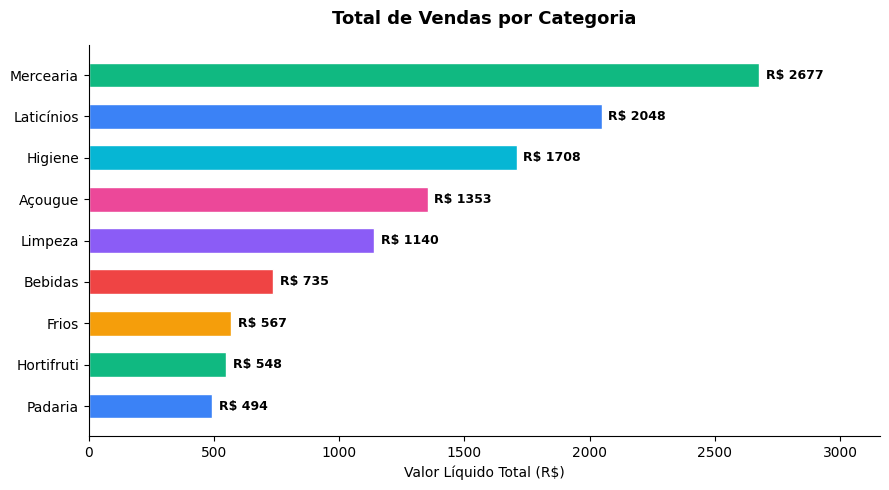

In [8]:
# Agrupando e somando por categoria
vendas_cat = (
    df_clean
    .groupby('Categoria')['Valor Líquido']
    .sum()
    .sort_values(ascending=False)
)

print("Total de vendas por categoria:")
for cat, val in vendas_cat.items():
    print(f"  {cat:<20} R$ {val:>8.2f}")

print()

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(9, 5))

cores = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#ec4899', '#06b6d4']

bars = ax.barh(
    vendas_cat.index[::-1],    # invertemos para o maior ficar no topo
    vendas_cat.values[::-1],
    color=cores[:len(vendas_cat)],
    edgecolor='white',
    height=0.6
)

# Anotações de valor em cada barra
max_val = vendas_cat.max()
for i, val in enumerate(vendas_cat.values[::-1]):
    ax.text(val + max_val * 0.01, i, f'R$ {val:.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Total de Vendas por Categoria', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Valor Líquido Total (R$)')
ax.set_xlim(0, max_val * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Resumo do Exercício

Você acabou de executar um **pipeline completo de limpeza e análise** de dados:

| Passo | O que foi feito | Técnica usada |
|---|---|---|
| 1 | Simular dados sujos | `np.random.choice`, `np.nan`, `pd.concat` |
| 2 | Diagnóstico | `isnull().sum()`, `duplicated().sum()` |
| 3 | Limpeza | `drop_duplicates`, `fillna(moda/mediana)`, filtro com `&` |
| 4 | Transformações | `.dt.month`, `pd.cut()` |
| 5 | Visualização | `groupby().sum()`, `barh` |

---

### Perguntas para reflexão

1. Por que removemos duplicatas **antes** de calcular a moda/mediana?
2. Em que situação seria melhor usar `dropna()` em vez de `fillna()`?
3. Se você mudasse os limites do `pd.cut()`, como isso afetaria a análise?
4. Por que o filtro `>= 1` e `<= 300` é uma decisão de negócio, e não puramente técnica?